In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score



In [41]:
df = pd.read_csv("housing.csv")
print("shape:", df.shape)
print("columns:", list(df.columns))

shape: (20640, 10)
columns: ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value', 'ocean_proximity']


In [42]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [43]:
print("\nMissing values:")
print(df.isnull().sum())
print("\nTarget Summary:")
print(df["median_house_value"].describe())


Missing values:
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

Target Summary:
count     20640.000000
mean     206855.816909
std      115395.615874
min       14999.000000
25%      119600.000000
50%      179700.000000
75%      264725.000000
max      500001.000000
Name: median_house_value, dtype: float64


In [44]:
df = df.dropna(subset=['total_bedrooms'])

In [45]:
df.isnull().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

In [46]:
X = df.drop(columns=['median_house_value', 'ocean_proximity'])
y = df['median_house_value']

print("\nX shape:", X.shape)
print("y shape:", y.shape)



X shape: (20433, 8)
y shape: (20433,)


In [47]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("\nX_train shape:", X_train.shape )
print("X_test shape:", X_test.shape)


X_train shape: (16346, 8)
X_test shape: (4087, 8)


In [48]:
scalar = StandardScaler()

X_train_scaled = scalar.fit_transform(X_train)
X_test_scaled = scalar.transform(X_test)

In [49]:
model = LinearRegression()

In [50]:
model.fit(X_train_scaled, y_train)

LinearRegression()

In [51]:
y_train_pred = model.predict(X_train_scaled)
y_test_scaled = model.predict(X_test_scaled)

In [52]:
print(y_train[:5])
print("-"*50)
y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)
print(y_test_pred[:5])


17727    227600.0
2057     110400.0
6453     248100.0
4619     305600.0
15266    214600.0
Name: median_house_value, dtype: float64
--------------------------------------------------
[197058.03752153 157508.79088918 202099.26270387 173501.82273784
 213795.18417458]


In [53]:
def print_regression_metrics(title, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    print(title)
    print(f" MAE: {mae:.2f}")
    print(f" MSE: {mse:.2f}")
    print(f" RMSE: {rmse:.2f}")
    print(f" R^2: {r2:.2f}")
    


In [54]:
print_regression_metrics("TRAIN METRICS", y_train, y_train_pred)
print_regression_metrics("TEST METRICS" , y_test, y_test_pred)

TRAIN METRICS
 MAE: 50629.50
 MSE: 4817977906.77
 RMSE: 69411.66
 R^2: 0.64
TEST METRICS
 MAE: 51372.67
 MSE: 4921881237.63
 RMSE: 70156.12
 R^2: 0.64


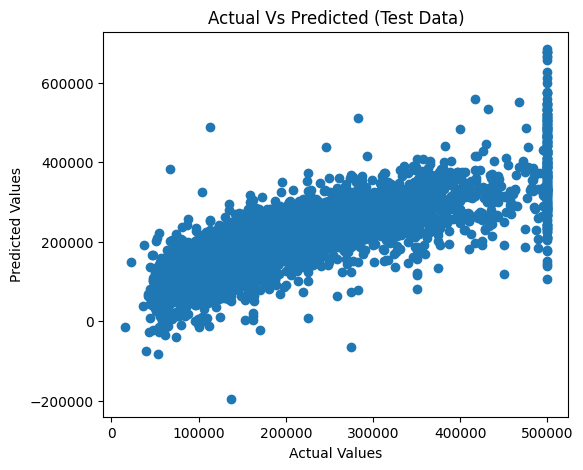

In [55]:
figsize = (6,5)
plt.figure(figsize=figsize)
plt.scatter(y_test, y_test_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual Vs Predicted (Test Data)")
plt.show()